# Load Data and Utilities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
import json
import torch

from diffusion import MaskedDiffusion
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


In [2]:
# find recursively all run dirs in the logs dir
logs_dir = "logs"
run_dirs = []
for root, dirs, files in os.walk(logs_dir):	
    if "events.out.tfevents" in " ".join(files):
        run_dirs.append(root)

In [3]:
def load_model_and_data(run_dir):
    ckpt_path = os.path.join(run_dir, "last.ckpt")
    model = MaskedDiffusion.load_from_checkpoint(ckpt_path).cpu()
    model.eval()

    dataset_path = os.path.join(run_dir, "dataset.pt")
    dataset_dict = torch.load(dataset_path, weights_only=False)
    train_data = dataset_dict["dataset"]["data"][dataset_dict["train_idx"]].cpu()
    val_data = dataset_dict["dataset"]["data"][dataset_dict["val_idx"]].cpu()
    return model, train_data, val_data

def compute_overlaps(samples, train_data):
    overlaps = torch.zeros((samples.shape[0], train_data.shape[0]))
    for i in range(samples.shape[0]):
        for j in range(train_data.shape[0]):
            overlaps[i, j] = (samples[i] * train_data[j]).sum().item() / samples.shape[1]

    top3_q = overlaps.topk(3, dim=1).values
    return overlaps, top3_q.mean(dim=0).tolist()

def read_hparams(run_dirs):
    data = []
    for run_dir in run_dirs:
        hparams_file = os.path.join(run_dir, "hparams.yaml")
        with open(hparams_file, "r") as f:
            lines = f.readlines()
        assert lines[0].startswith("config:")
        if lines and lines[0].startswith("config: !!python/object:"):
            # Remove the tag but keep the key ("config:")
            lines[0] = "config:\n"
        hparams = yaml.safe_load("".join(lines))
        hparams["config"]["run_dir"] = run_dir
        data.append(hparams["config"])
    df = pd.DataFrame(data)

    for col in ["no_pbar", "save_dataset", "test", "eps", "seed", "lr", "pbar", "alpha_val"]:
        if col in df.columns:
            df = df.drop(columns=[col])


    
    df = df.sort_values(by=["L", "alpha", "l2reg"]).reset_index(drop=True)
    return df

def read_test_results(run_dirs, save_fixed=False):
    data = []
    for run_dir in run_dirs:
        test_results_file = os.path.join(run_dir, "test_results.json")
        if not os.path.exists(test_results_file):
            continue
        with open(test_results_file, "r") as f:
            test_results = json.load(f)
        # assert isinstance(test_results, list) and len(test_results) == 1
        assert isinstance(test_results, list)
        test_results[0]["run_dir"] = run_dir # only consider train results for dataloader_idx_0
        
        # Fix keys from old runs
        for d in test_results:
            for key in list(d.keys()):
                if key.endswith("/dataloader_idx_0"):
                    new_key = key.replace("/dataloader_idx_0", "").replace("test/", "train/")
                    d[new_key] = d.pop(key)
                elif key.endswith("/dataloader_idx_1"):
                    new_key = key.replace("/dataloader_idx_1", "").replace("test/", "val/")
                    d[new_key] = d.pop(key)

        # Add top3 overlaps if missing
        d = test_results[0]
        if "sample/top3_overlaps_with_train" not in d:
            if os.path.exists(os.path.join(run_dir, "samples.pt")):
                samples = torch.load(os.path.join(run_dir, "samples.pt"))
                model, train_data, val_data = load_model_and_data(run_dir)
                overlaps, top3_q = compute_overlaps(samples, train_data)
                d["sample/top3_overlaps_with_train"] = top3_q

        if save_fixed:
            # resave fixed test results
            with open(test_results_file, "w") as f:
                json.dump(test_results, f, indent=4)

        data.append(test_results[0])
    df = pd.DataFrame(data)
    return df


In [4]:
def merge_right_prefer(left, right, on, how="outer"):
    # Merge keeping right-hand values on overlapping columns; fall back to left when right is NaN
    on_cols = [on] if isinstance(on, str) else list(on)
    overlap = [c for c in left.columns.intersection(right.columns) if c not in on_cols]
    merged = left.merge(right, on=on_cols, how=how, suffixes=("_left", "_right"))
    for c in overlap:
        rc = f"{c}_right"
        lc = f"{c}_left"
        # prefer right; if right is NaN, use left
        merged[c] = merged[rc].combine_first(merged[lc])
        merged = merged.drop(columns=[lc, rc])
    return merged

df_hparams = read_hparams(run_dirs)
df_test_results = read_test_results(run_dirs)
df_all = merge_right_prefer(df_hparams, df_test_results, on="run_dir", how="outer")
df_all = df_all.sort_values(by=["dataset", "model", "L", "alpha", "l2reg"]).reset_index(drop=True)
df_all

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,exp_dir,freeze_mask_weights,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,784,0.05,512,binarized_mnist,10000,0.000,linear,logs/linear_binarized_mnist_L784_alpha0.05_l2r...,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,784,0.10,512,binarized_mnist,10000,0.000,linear,logs/linear_binarized_mnist_L784_alpha0.1_l2re...,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,0.10,512,binarized_mnist,10000,0.001,linear,logs/linear_binarized_mnist_L784_alpha0.1_l2re...,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,784,0.10,512,binarized_mnist,10000,0.010,linear,logs/linear_binarized_mnist_L784_alpha0.1_l2re...,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,784,1.00,512,binarized_mnist,10000,0.000,linear,logs/linear_binarized_mnist_L784_alpha1.0_l2re...,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,4096,0.10,512,uniform,5000,0.000,linear,logs/linear_uniform_L4096_alpha0.1_l2reg0.0/ve...,NaN,NaN,...,0.997902,0.377571,0.831966,0.755147,0.504588,1.000000,0.999352,0.666459,0.004216,"[0.1338476538658142, 0.11920410394668579, 0.11..."
63,4096,0.50,512,uniform,5000,0.000,linear,logs/linear_uniform_L4096_alpha0.5_l2reg0.0/ve...,NaN,NaN,...,0.873030,0.660258,0.653592,0.724963,0.500774,0.995115,0.840989,0.242432,0.000497,"[0.0857250988483429, 0.07857909798622131, 0.07..."
64,8192,0.05,512,uniform,5000,0.000,linear,logs/linear_uniform_L8192_alpha0.05_l2reg0.0/v...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,8192,0.10,512,uniform,5000,0.000,linear,logs/linear_uniform_L8192_alpha0.1_l2reg0.0/ve...,NaN,NaN,...,0.997324,0.418227,0.823396,0.820599,0.501807,1.000000,0.999403,0.658888,0.001020,"[0.09812500327825546, 0.08870483189821243, 0.0..."


## Add TensorBoard data

In [5]:
def load_scalars_from_event(logdir):
    """Return a DataFrame of all scalar tags in a single TensorBoard run."""
    ea = EventAccumulator(logdir)
    ea.Reload()
    data = []
    for tag in ea.Tags()['scalars']:
        for s in ea.Scalars(tag):
            data.append({
                'tag': tag,
                'step': s.step,
                'value': s.value,
                'wall_time': s.wall_time
            })
    df_tb = pd.DataFrame(data)
       
    df_tb = df_tb.drop_duplicates(["tag", "step"])
    df_tb = df_tb.pivot(index="step", columns="tag", values="value")
    df_tb = df_tb.drop(columns=["hp_metric"])
    df_tb["epoch"] = df_tb["epoch"].bfill()
    df_tb["epoch"] = df_tb["epoch"].astype(int)
    df_tb = df_tb.reset_index()
    df_tb = df_tb.drop(columns=["step"])
    df_tb = df_tb.groupby("epoch").mean()
    df_tb.columns.name = None
    df_tb = df_tb.reset_index()
    return df_tb

Now we compute the mean values using the last 10% epochs. 

In [6]:

tb_means = []
for run_dir in df_all["run_dir"]:
    print(run_dir)
    event_files = [f for f in os.listdir(run_dir) if f.startswith("events.out.tfevents")]
    # assert len(event_files) == 2 # there should be two event files, one for train and one for test
    if event_files[0].endswith(".0"):
        train_event_file = event_files[0]
    else:
        train_event_file = event_files[1]
    assert train_event_file.endswith(".0")  # we load the train event file
    df_tb = load_scalars_from_event(os.path.join(run_dir, train_event_file))
    nrows = df_tb.shape[0]
    # assert (df_tb.epoch == np.arange(nrows)).all()
    # # average all columns except "epoch" and "step" over last 10% epochs
    tb_mean = df_tb.iloc[int(0.9*nrows):].mean()
    tb_mean.drop(labels=["epoch"], inplace=True)
    tb_mean["run_dir"] = run_dir
    tb_means.append(tb_mean)
df_tb_mean = pd.DataFrame(tb_means)
df_tb_mean

logs/linear_binarized_mnist_L784_alpha0.05_l2reg0.0/version_0/MBP14.station
logs/linear_binarized_mnist_L784_alpha0.1_l2reg0.0/version_0/MBP14.station
logs/linear_binarized_mnist_L784_alpha0.1_l2reg0.001/version_0/MBP14.station
logs/linear_binarized_mnist_L784_alpha0.1_l2reg0.01/version_0/MBP14.station
logs/linear_binarized_mnist_L784_alpha1.0_l2reg0.0/version_0/MBP14.station
logs/linear_uniform_L128_alpha0.05_l2reg0.0/version_0/mbp14.local
logs/linear_uniform_L128_alpha0.1_l2reg0.0/version_1/mac
logs/linear_uniform_L128_alpha0.1_l2reg0.0/version_2/mac
logs/linear_uniform_L256_alpha0.05_l2reg0.0/version_0/cnode06
logs/linear_uniform_L256_alpha0.1_l2reg0.0/version_0/cnode05
logs/linear_uniform_L256_alpha0.1_l2reg0.0/version_4/mac
logs/linear_uniform_L256_alpha0.1_l2reg0.01/version_0/cnode08
logs/linear_uniform_L256_alpha0.1_l2reg0.01_fmw/version_0/cnode08
logs/linear_uniform_L256_alpha0.2_l2reg0.01/version_0/cnode08
logs/linear_uniform_L256_alpha0.2_l2reg0.01_fmw/version_0/cnode08
logs/

,train/acc,train/l2loss,train/loss,train/qV,train/qW,train/total_loss,val/acc,val/loss,run_dir
0,0.978566,0.000000,0.028811,0.837958,19.259155,0.028811,0.907103,0.443839,logs/linear_binarized_mnist_L784_alpha0.05_l2r...
1,0.970557,0.000000,0.040143,1.416444,20.688181,0.040143,0.917982,0.305942,logs/linear_binarized_mnist_L784_alpha0.1_l2re...
2,0.964552,0.017773,0.058023,0.192525,3.362093,0.075796,0.917814,0.193729,logs/linear_binarized_mnist_L784_alpha0.1_l2re...
3,0.950773,0.034253,0.100144,0.032892,0.652162,0.134397,0.913595,0.178407,logs/linear_binarized_mnist_L784_alpha0.1_l2re...
4,0.944960,0.000000,0.089016,3.977633,23.019995,0.089016,0.929678,0.148439,logs/linear_binarized_mnist_L784_alpha1.0_l2re...
...,...,...,...,...,...,...,...,...,...
62,0.918616,NaN,0.097585,NaN,NaN,NaN,NaN,NaN,logs/linear_uniform_L4096_alpha0.1_l2reg0.0/ve...
63,0.774441,NaN,0.324634,NaN,NaN,NaN,NaN,NaN,logs/linear_uniform_L4096_alpha0.5_l2reg0.0/ve...
64,0.946228,NaN,0.066657,NaN,NaN,NaN,NaN,NaN,logs/linear_uniform_L8192_alpha0.05_l2reg0.0/v...
65,0.913950,NaN,0.107753,NaN,NaN,NaN,NaN,NaN,logs/linear_uniform_L8192_alpha0.1_l2reg0.0/ve...


In [7]:
df_all = merge_right_prefer(df_all, df_tb_mean, on="run_dir", how="outer")
df_all.to_csv("experiments.csv", index=False)

# U-Turn from training points

## Linear Model - Uniform Data

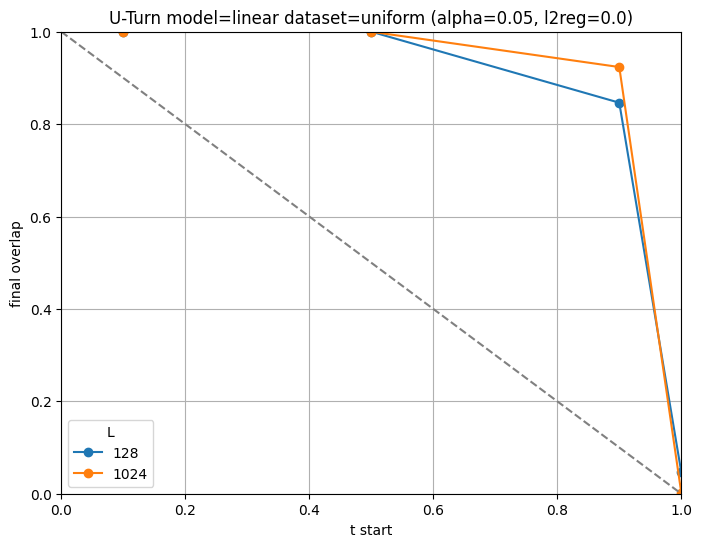

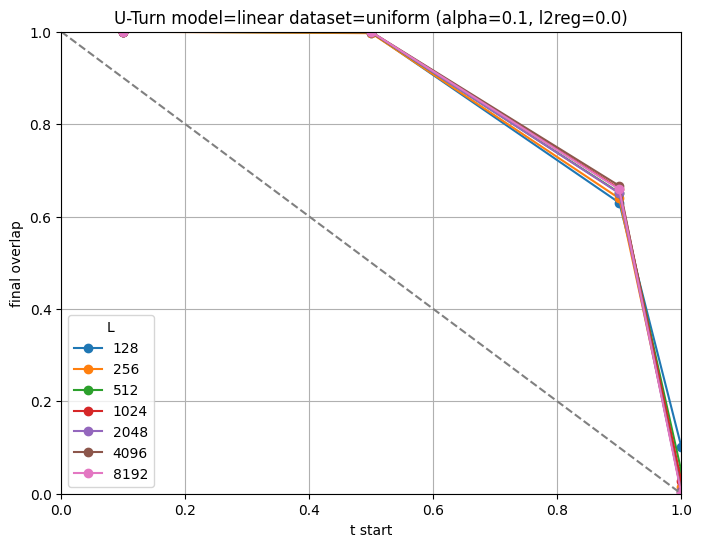

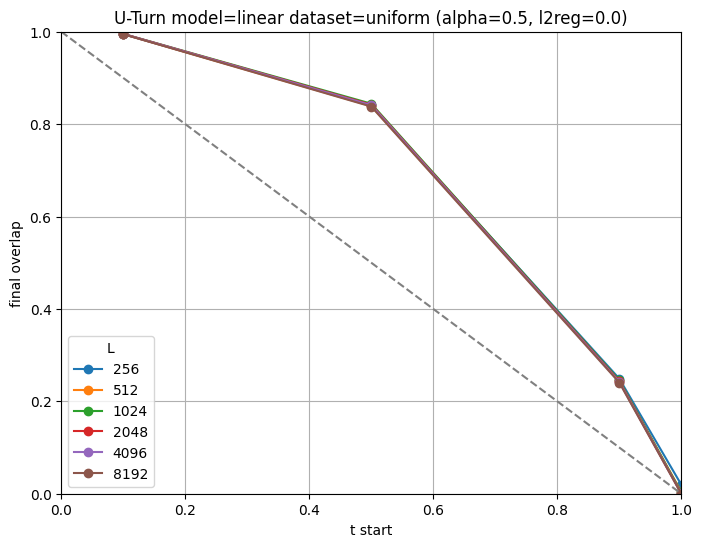

In [421]:
model_t = "linear"
dataset = "uniform"
l2reg = 0.0
df_small = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg)]
for alpha in [0.05, 0.1, 0.5]:
    df = df_small[df_small["alpha"] == alpha]
    t_strings = ["0.1", "0.5", "0.9", "1.0"] 
    ts = [float(s) for s in t_strings]
    Ls = sorted(df["L"].unique())

    plt.close("all")
    plt.figure(figsize=(8,6))
    plt.xlabel("t start")
    plt.ylabel("final overlap")
    plt.title(f"U-Turn model={model_t} dataset={dataset} (alpha={alpha}, l2reg={l2reg})")
    # plt.xticks(ts)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    for L in Ls:
        df_L = df[df["L"] == L]
        ys = []
        for t in t_strings:
            col = f"train/uturn_overlap_t{t}"
            ys.append(df_L[col].mean())
        plt.plot(ts, ys, label=f"{L}", marker="o")
    plt.legend(loc="lower left", title="L")
    # plot diagonal line from (0,1) to (1,0)
    plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

    plt.grid()
    plt.savefig(f"notes/plots/uturn_{model_t}_{dataset}_alpha{alpha}_l2reg{l2reg}.png", dpi=300)

    plt.show()

In [422]:
L = 1024
dataset = "uniform"
l2reg = 0.0
model_t = "linear"
df = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg) & (df_all["L"] == L)]
df = df.sort_values(by="alpha")
df = df.reset_index(drop=True)
df


,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,1024,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.05_l2reg0.0/v...,0.938654,0.071569,...,0.999992,0.215688,0.917924,0.741310,0.526482,1.000000,0.999962,0.923560,0.001991,"[0.28151366114616394, 0.22833985090255737, 0.2..."
1,1024,0.10,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.1_l2reg0.0/ve...,0.912814,0.106308,...,0.998344,0.361953,0.838476,0.720903,0.520374,1.000000,0.998889,0.660635,0.026942,"[0.23087890446186066, 0.1946386694908142, 0.17..."
2,1024,0.20,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.2_l2reg0.0/ve...,0.853173,0.190533,...,0.977606,0.502938,0.756268,0.707563,0.514815,0.999981,0.986538,0.411357,-0.004621,"[0.18446289002895355, 0.16420897841453552, 0.1..."
3,1024,0.50,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.5_l2reg0.0/ve...,0.770498,0.320814,...,0.880272,0.631561,0.662491,0.700246,0.507946,0.995262,0.844200,0.245735,0.002953,"[0.15391601622104645, 0.13804687559604645, 0.1..."
4,1024,1.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha1.0_l2reg0.0/ve...,0.708847,0.444736,...,0.776168,0.672224,0.611315,0.698268,0.503936,0.968372,0.696648,0.178158,0.001623,"[0.1378515660762787, 0.12513671815395355, 0.11..."
5,1024,1.50,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha1.5_l2reg0.0/ve...,0.663690,0.537682,...,0.723124,0.679931,0.589078,0.699260,0.502180,0.949070,0.639796,0.153406,0.000398,"[0.13098633289337158, 0.12103515863418579, 0.1..."
6,1024,2.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha2.0_l2reg0.0/ve...,0.639757,0.577526,...,0.690410,0.683079,0.576163,0.698935,0.501577,0.938302,0.609125,0.141244,-0.000305,"[0.12916992604732513, 0.11923827975988388, 0.1..."
7,1024,3.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha3.0_l2reg0.0/ve...,0.611312,0.624777,...,0.650413,0.688671,0.558919,0.699791,0.501113,0.926200,0.574765,0.127786,0.001197,"[0.12729492783546448, 0.11784179508686066, 0.1..."
8,1024,4.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha4.0_l2reg0.0/ve...,0.592337,0.647028,...,0.626845,0.691942,0.548793,0.700241,0.501205,0.920479,0.558064,0.122377,0.000243,"[0.12596680223941803, 0.11717773228883743, 0.1..."
9,1024,8.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha8.0_l2reg0.0/ve...,0.558324,0.679307,...,0.580539,0.696537,0.529405,0.699405,0.500345,0.910624,0.529540,0.111690,-0.000079,"[0.12647460401058197, 0.11749999970197678, 0.1..."


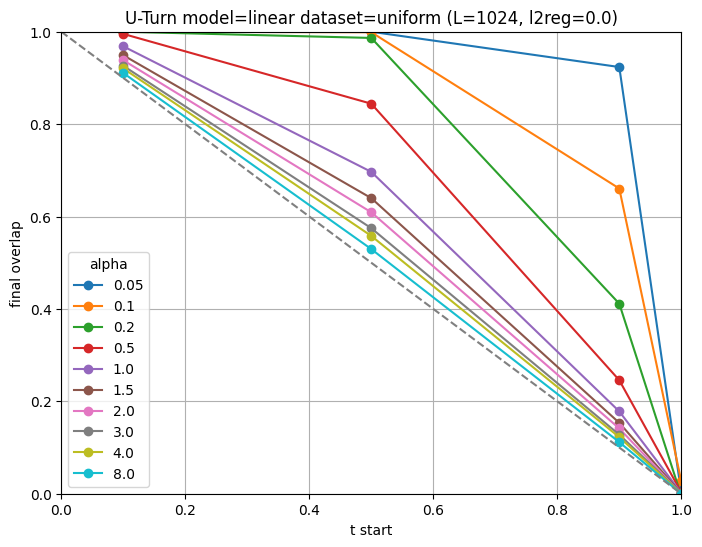

In [423]:
t_strings = ["0.1", "0.5", "0.9", "1.0"] 
ts = [float(s) for s in t_strings]
alphas = sorted(df["alpha"].unique())

plt.close("all")
plt.figure(figsize=(8,6))
plt.xlabel("t start")
plt.ylabel("final overlap")
plt.title(f"U-Turn model={model_t} dataset={dataset} (L={L}, l2reg={l2reg})")
# plt.xticks(ts)
plt.ylim(0, 1)
plt.xlim(0, 1)
for alpha in alphas:
    df_alpha = df[df["alpha"] == alpha]
    ys = []
    for t in t_strings:
        col = f"train/uturn_overlap_t{t}"
        ys.append(df_alpha[col].mean())
    plt.plot(ts, ys, label=f"{alpha}", marker="o")
plt.legend(loc="lower left", title="alpha")
# plot diagonal line from (0,1) to (1,0)
plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

plt.grid()
plt.savefig(f"notes/plots/uturn_{model_t}_{dataset}_L{L}_l2reg{l2reg}.png", dpi=300)

plt.show()

## Tensor Model - Uniform Data

In [5]:
model_t = "tensor8"
dataset = "uniform"
l2reg = 0.0
df_small = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg)]
df_small

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
75,128,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L128_alpha0.1_l2reg0.0/ve...,0.945233,0.115884,...,0.997347,0.393802,0.838252,0.671278,0.591947,0.998798,0.981971,0.641827,-0.045673,"[0.5096874833106995, 0.31562501192092896, 0.23..."
76,128,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L128_alpha0.1_l2reg0.0/ve...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,128,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L128_alpha0.1_l2reg0.0/ve...,0.907891,0.143954,...,0.998803,0.383372,0.845672,0.664574,0.603966,0.992788,0.991587,0.620192,0.091346,"[0.5082812309265137, 0.3394531309604645, 0.251..."
78,128,0.5,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L128_alpha0.5_l2reg0.0/ve...,0.788202,0.358157,...,0.882688,0.604028,0.668771,0.688889,0.545654,0.971680,0.808105,0.216064,0.012695,"[0.3385937511920929, 0.28664061427116394, 0.25..."
79,256,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L256_alpha0.1_l2reg0.0/ve...,0.940613,0.095671,...,0.998058,0.386692,0.832748,0.695507,0.564153,0.998798,0.990084,0.617488,0.046875,"[0.38050782680511475, 0.28589844703674316, 0.2..."
80,256,0.5,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L256_alpha0.5_l2reg0.0/ve...,0.777117,0.331251,...,0.877020,0.609340,0.664646,0.697096,0.526855,0.980042,0.808777,0.248230,0.009033,"[0.2623046934604645, 0.2296484410762787, 0.208..."
81,512,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L512_alpha0.1_l2reg0.0/ve...,0.887682,0.133992,...,0.997840,0.381695,0.830354,0.717488,0.536267,0.999387,0.994945,0.637944,0.005055,"[0.29912108182907104, 0.2412109375, 0.21208983..."
82,512,0.5,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L512_alpha0.5_l2reg0.0/ve...,0.790385,0.304784,...,0.877127,0.611149,0.663756,0.699060,0.513947,0.985657,0.822678,0.237625,0.004990,"[0.19640624523162842, 0.17511719465255737, 0.1..."
83,1024,0.1,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L1024_alpha0.1_l2reg0.0/v...,0.933812,0.092983,...,0.997403,0.375977,0.831560,0.723144,0.514907,0.999311,0.995653,0.629098,0.017138,"[0.22279296815395355, 0.1897558569908142, 0.17..."
84,1024,0.5,512,uniform,5000,0.0,tensor8,logs/tensor8_uniform_L1024_alpha0.5_l2reg0.0/v...,0.783187,0.311140,...,0.874361,0.616323,0.660571,0.703891,0.504707,0.989525,0.833408,0.239674,0.003090,"[0.1514257788658142, 0.13527344167232513, 0.12..."


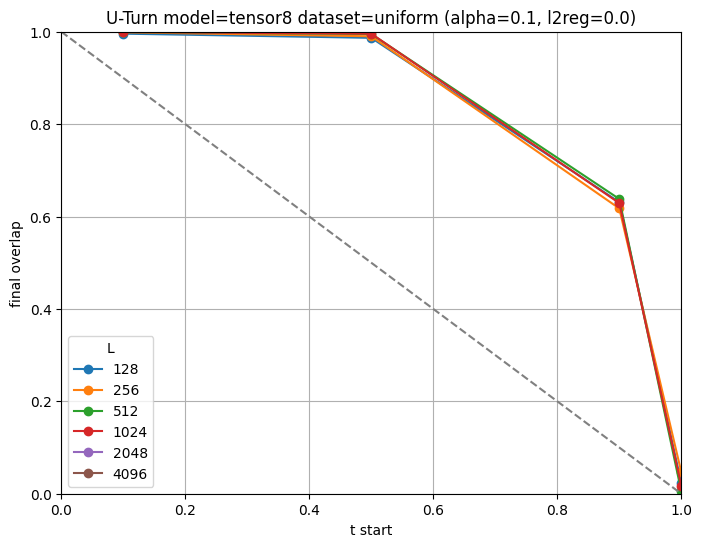

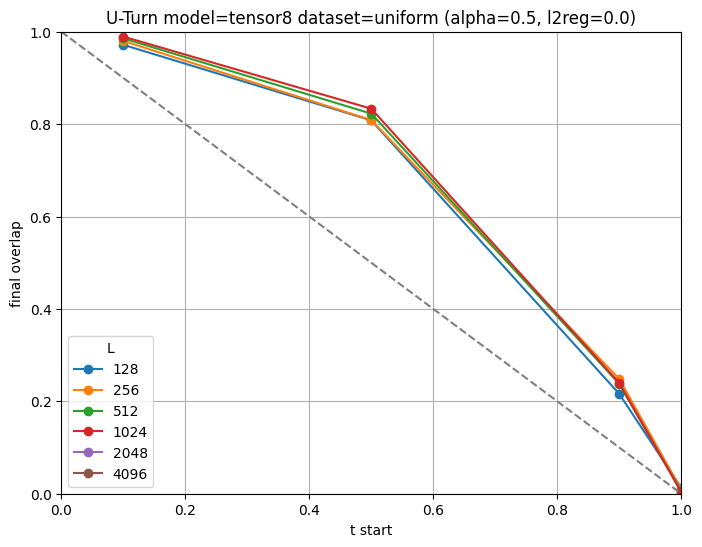

In [6]:
for alpha in [0.1, 0.5]:
    df = df_small[df_small["alpha"] == alpha]
    t_strings = ["0.1", "0.5", "0.9", "1.0"] 
    ts = [float(s) for s in t_strings]
    Ls = sorted(df["L"].unique())

    plt.close("all")
    plt.figure(figsize=(8,6))
    plt.xlabel("t start")
    plt.ylabel("final overlap")
    plt.title(f"U-Turn model={model_t} dataset={dataset} (alpha={alpha}, l2reg={l2reg})")
    # plt.xticks(ts)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    for L in Ls:
        df_L = df[df["L"] == L]
        ys = []
        for t in t_strings:
            col = f"train/uturn_overlap_t{t}"
            ys.append(df_L[col].mean())
        plt.plot(ts, ys, label=f"{L}", marker="o")
    plt.legend(loc="lower left", title="L")
    # plot diagonal line from (0,1) to (1,0)
    plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

    plt.grid()
    plt.savefig(f"notes/plots/uturn_{model_t}_{dataset}_alpha{alpha}_l2reg{l2reg}.png", dpi=300)

    plt.show()

In [448]:
L = 1024
dataset = "uniform"
l2reg = 0.0
model_t = "linear"
df = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg) & (df_all["L"] == L)]
df = df.sort_values(by="alpha")
df = df.reset_index(drop=True)
df


,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,1024,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.05_l2reg0.0/v...,0.938654,0.071569,...,0.999992,0.215688,0.917924,0.741310,0.526482,1.000000,0.999962,0.923560,0.001991,"[0.28151366114616394, 0.22833985090255737, 0.2..."
1,1024,0.10,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.1_l2reg0.0/ve...,0.912814,0.106308,...,0.998344,0.361953,0.838476,0.720903,0.520374,1.000000,0.998889,0.660635,0.026942,"[0.23087890446186066, 0.1946386694908142, 0.17..."
2,1024,0.20,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.2_l2reg0.0/ve...,0.853173,0.190533,...,0.977606,0.502938,0.756268,0.707563,0.514815,0.999981,0.986538,0.411357,-0.004621,"[0.18446289002895355, 0.16420897841453552, 0.1..."
3,1024,0.50,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.5_l2reg0.0/ve...,0.770498,0.320814,...,0.880272,0.631561,0.662491,0.700246,0.507946,0.995262,0.844200,0.245735,0.002953,"[0.15391601622104645, 0.13804687559604645, 0.1..."
4,1024,1.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha1.0_l2reg0.0/ve...,0.708847,0.444736,...,0.776168,0.672224,0.611315,0.698268,0.503936,0.968372,0.696648,0.178158,0.001623,"[0.1378515660762787, 0.12513671815395355, 0.11..."
5,1024,1.50,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha1.5_l2reg0.0/ve...,0.663690,0.537682,...,0.723124,0.679931,0.589078,0.699260,0.502180,0.949070,0.639796,0.153406,0.000398,"[0.13098633289337158, 0.12103515863418579, 0.1..."
6,1024,2.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha2.0_l2reg0.0/ve...,0.639757,0.577526,...,0.690410,0.683079,0.576163,0.698935,0.501577,0.938302,0.609125,0.141244,-0.000305,"[0.12916992604732513, 0.11923827975988388, 0.1..."
7,1024,3.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha3.0_l2reg0.0/ve...,0.611312,0.624777,...,0.650413,0.688671,0.558919,0.699791,0.501113,0.926200,0.574765,0.127786,0.001197,"[0.12729492783546448, 0.11784179508686066, 0.1..."
8,1024,4.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha4.0_l2reg0.0/ve...,0.592337,0.647028,...,0.626845,0.691942,0.548793,0.700241,0.501205,0.920479,0.558064,0.122377,0.000243,"[0.12596680223941803, 0.11717773228883743, 0.1..."
9,1024,8.00,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha8.0_l2reg0.0/ve...,0.558324,0.679307,...,0.580539,0.696537,0.529405,0.699405,0.500345,0.910624,0.529540,0.111690,-0.000079,"[0.12647460401058197, 0.11749999970197678, 0.1..."


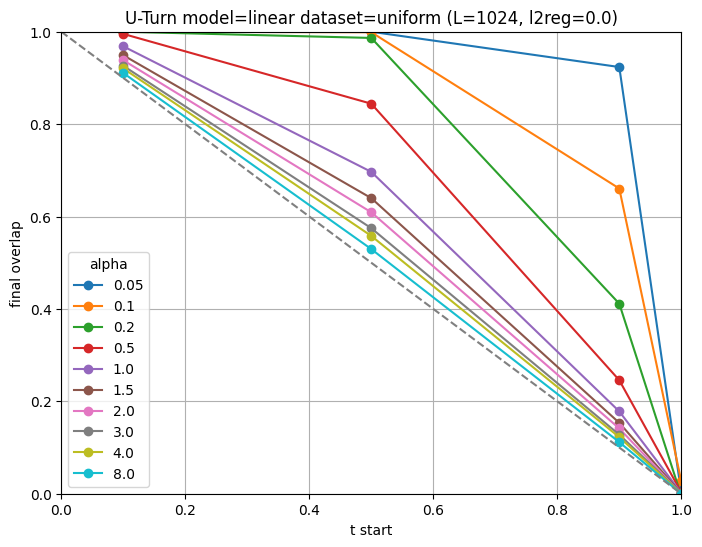

In [ ]:
t_strings = ["0.1", "0.5", "0.9", "1.0"] 
ts = [float(s) for s in t_strings]
alphas = sorted(df["alpha"].unique())

plt.close("all")
plt.figure(figsize=(8,6))
plt.xlabel("t start")
plt.ylabel("final overlap")
plt.title(f"U-Turn model={model_t} dataset={dataset} (L={L}, l2reg={l2reg})")
# plt.xticks(ts)
plt.ylim(0, 1)
plt.xlim(0, 1)
for alpha in alphas:
    df_alpha = df[df["alpha"] == alpha]
    ys = []
    for t in t_strings:
        col = f"train/uturn_overlap_t{t}"
        ys.append(df_alpha[col].mean())
    plt.plot(ts, ys, label=f"{alpha}", marker="o")
plt.legend(loc="lower left", title="alpha")
# plot diagonal line from (0,1) to (1,0)
plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

plt.grid()
plt.savefig(f"notes/plots/uturn_{model_t}_{dataset}_L{L}_l2reg{l2reg}.png", dpi=300)

plt.show()

## All models - Uniform Data

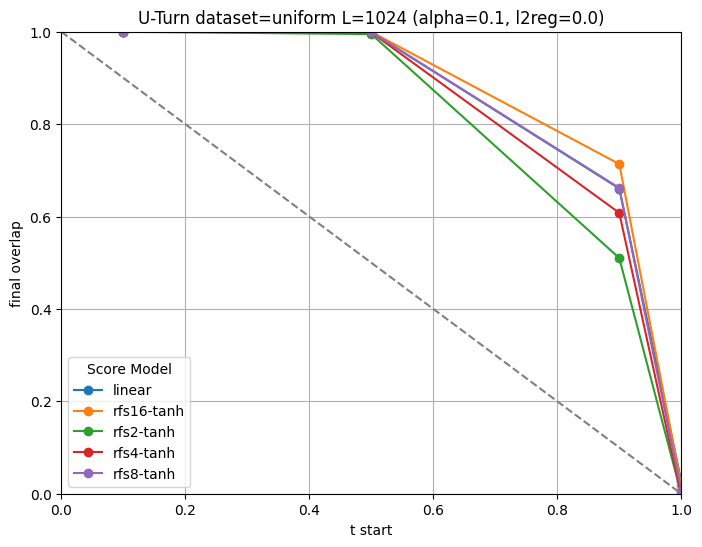

In [179]:
L = 1024
alpha = 0.1
dataset = "uniform"
l2reg = 0.0

df = df_all[(df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg) & (df_all["L"] == L) & (df_all["alpha"] == alpha)]
t_strings = ["0.1", "0.5", "0.9", "1.0"] 
ts = [float(s) for s in t_strings]
Ls = sorted(df["L"].unique())

plt.close("all")
plt.figure(figsize=(8,6))
plt.xlabel("t start")
plt.ylabel("final overlap")
plt.title(f"U-Turn dataset={dataset} L={L} (alpha={alpha}, l2reg={l2reg})")
# plt.xticks(ts)
plt.ylim(0, 1)
plt.xlim(0, 1)
for model in sorted(df["model"].unique()):
    df_model = df[df["model"] == model]
    ys = []
    for t in t_strings:
        col = f"train/uturn_overlap_t{t}"
        ys.append(df_model[col].mean())
    plt.plot(ts, ys, label=f"{model}", marker="o")
plt.legend(loc="lower left", title="Score Model")
# plot diagonal line from (0,1) to (1,0)
plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

plt.grid()
plt.savefig(f"notes/plots/uturn_allmodels_{dataset}_L{L}_alpha{alpha}_l2reg{l2reg}.png", dpi=300)

plt.show()

## Linear Model - Random Feature Data

In [288]:
model_t = "linear"
dataset = "rf"
L = 512
l2reg = 0.0
df_small = df_all[(df_all["model"] == model_t) &
                  (df_all["dataset"].str.startswith(dataset)) &
                  (df_all["l2reg"] == l2reg) &
                  (df_all["L"] == L)]
df_small = df_small.sort_values(by=["alpha", "dataset"])
df_small = df_small.reset_index(drop=True)
df_small

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,512,0.1,512,rf2,5000,0.0,linear,logs/linear_rf2_L512_alpha0.1_l2reg0.0/version...,0.928241,0.089938,...,0.998426,0.349492,0.847807,0.704515,0.538143,1.000000,0.999004,0.653263,0.006510,"[0.31595703959465027, 0.2527539134025574, 0.22..."
1,512,0.1,512,rf4,5000,0.0,linear,logs/linear_rf4_L512_alpha0.1_l2reg0.0/version...,0.909105,0.101544,...,0.998273,0.344482,0.850863,0.709228,0.533127,1.000000,0.998392,0.674632,0.041513,"[0.3186914026737213, 0.2581250071525574, 0.228..."
2,512,0.1,512,rf8,5000,0.0,linear,logs/linear_rf8_L512_alpha0.1_l2reg0.0/version...,0.947868,0.061558,...,0.998363,0.331116,0.858198,0.708690,0.534850,1.000000,0.998468,0.691330,0.025812,"[0.33525389432907104, 0.27955079078674316, 0.2..."
3,512,0.2,512,rf2,5000,0.0,linear,logs/linear_rf2_L512_alpha0.2_l2reg0.0/version...,0.855106,0.178838,...,0.980036,0.477891,0.769477,0.703675,0.525754,0.999962,0.985141,0.441406,0.006089,"[0.2633593678474426, 0.22583983838558197, 0.20..."
4,512,0.2,512,rf4,5000,0.0,linear,logs/linear_rf4_L512_alpha0.2_l2reg0.0/version...,0.882920,0.142605,...,0.981295,0.460324,0.779948,0.700458,0.527037,0.999962,0.987132,0.461627,0.016314,"[0.2718164026737213, 0.23585937917232513, 0.21..."
5,512,0.2,512,rf8,5000,0.0,linear,logs/linear_rf8_L512_alpha0.2_l2reg0.0/version...,0.898962,0.137904,...,0.984738,0.436460,0.794846,0.706200,0.520489,1.000000,0.989698,0.531748,-0.005898,"[0.30617186427116394, 0.25779297947883606, 0.2..."
6,512,0.5,512,rf2,5000,0.0,linear,logs/linear_rf2_L512_alpha0.5_l2reg0.0/version...,0.812809,0.275331,...,0.901533,0.599858,0.684324,0.699047,0.513489,0.996475,0.875977,0.286392,0.001755,"[0.22285155951976776, 0.1984570324420929, 0.18..."
7,512,0.5,512,rf4,5000,0.0,linear,logs/linear_rf4_L512_alpha0.5_l2reg0.0/version...,0.821739,0.236134,...,0.917858,0.574616,0.703212,0.696463,0.516525,0.997742,0.903397,0.330551,0.001984,"[0.24189452826976776, 0.2156640589237213, 0.20..."
8,512,0.5,512,rf8,5000,0.0,linear,logs/linear_rf8_L512_alpha0.5_l2reg0.0/version...,0.840313,0.217096,...,0.938777,0.532536,0.732521,0.699825,0.510284,0.998169,0.937073,0.402344,0.003220,"[0.2800585925579071, 0.24769531190395355, 0.22..."
9,512,1.0,512,rf2,5000,0.0,linear,logs/linear_rf2_L512_alpha1.0_l2reg0.0/version...,0.751076,0.366544,...,0.831736,0.638406,0.644847,0.695719,0.509335,0.980812,0.770760,0.226112,0.002647,"[0.20560546219348907, 0.18720702826976776, 0.1..."


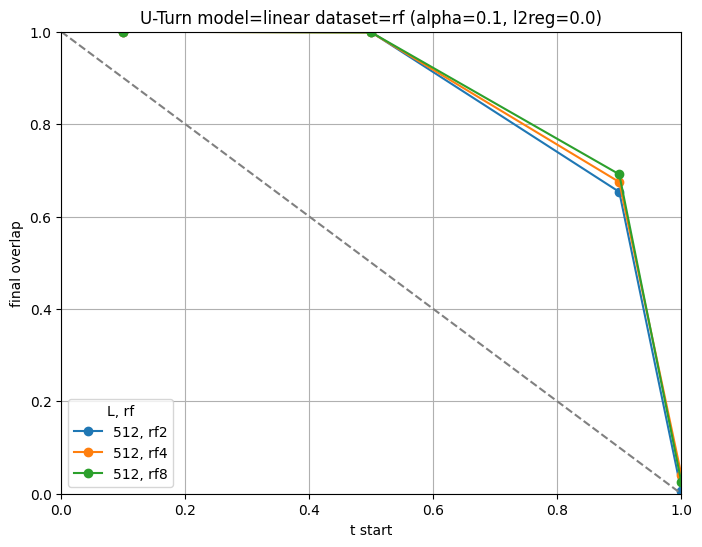

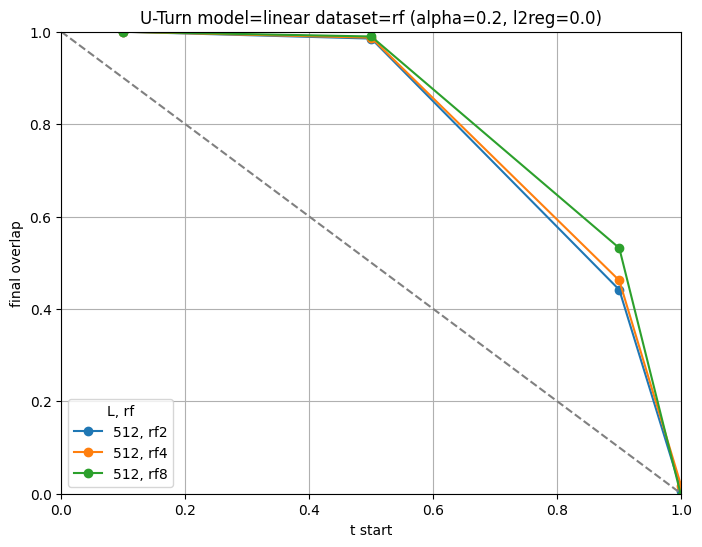

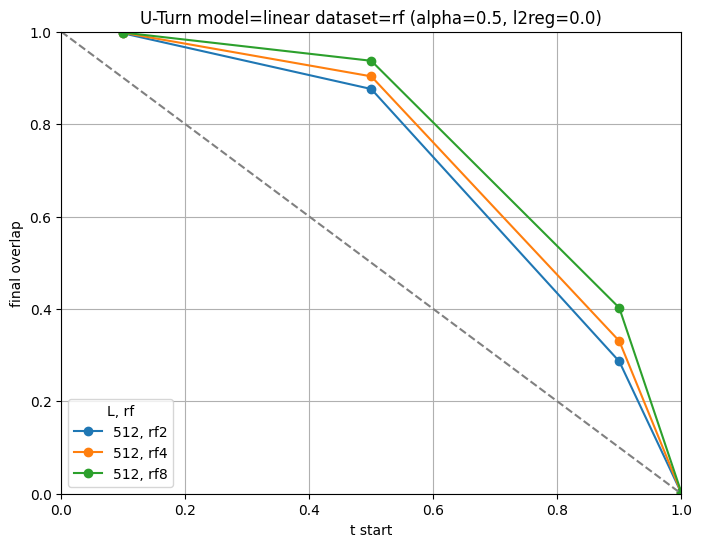

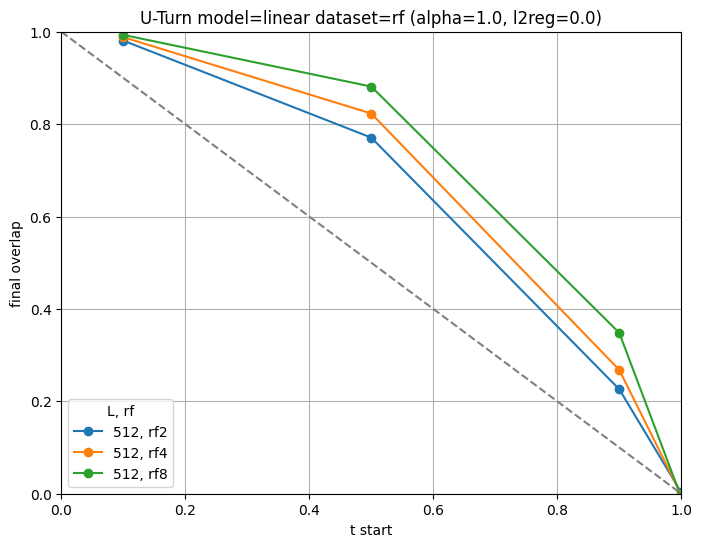

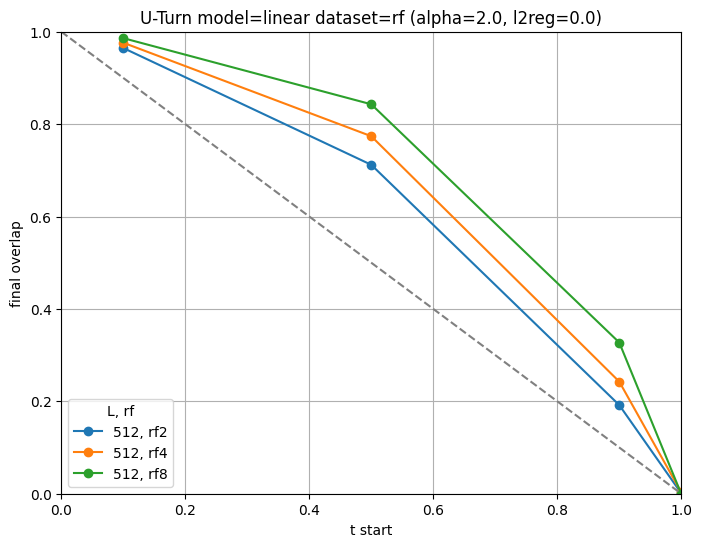

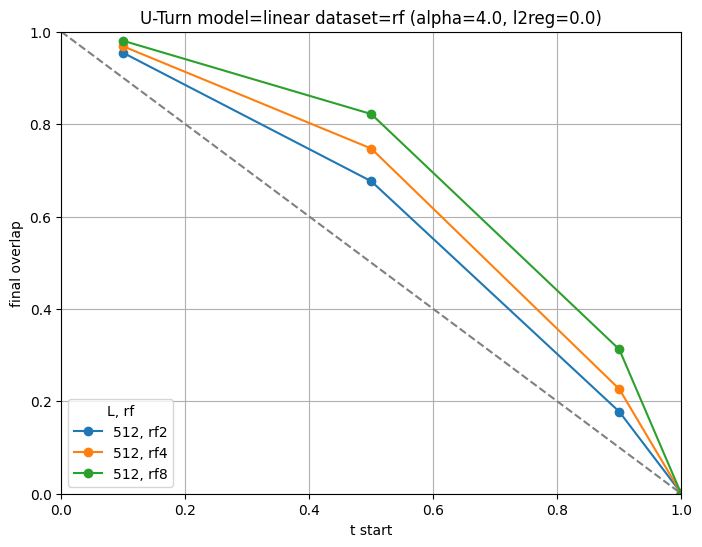

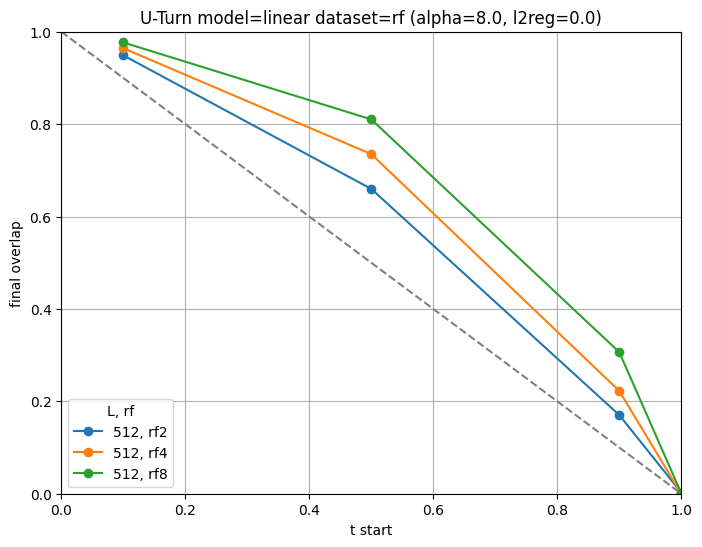

In [289]:
for alpha in df_small["alpha"].unique():
    df = df_small[df_small["alpha"] == alpha]
    t_strings = ["0.1", "0.5", "0.9", "1.0"] 
    ts = [float(s) for s in t_strings]
    Ls = sorted(df["L"].unique())

    plt.close("all")
    plt.figure(figsize=(8,6))
    plt.xlabel("t start")
    plt.ylabel("final overlap")
    plt.title(f"U-Turn model={model_t} dataset={dataset} (alpha={alpha}, l2reg={l2reg})")
    # plt.xticks(ts)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    for rf in ["rf2", "rf4", "rf8"]:
        df_L = df[(df["L"] == L) & (df["dataset"].str.startswith(rf))]
        ys = []
        for t in t_strings:
            col = f"train/uturn_overlap_t{t}"
            ys.append(df_L[col].mean())
        plt.plot(ts, ys, label=f"{L}, {rf}", marker="o")
    plt.legend(loc="lower left", title="L, rf")
    # plot diagonal line from (0,1) to (1,0)
    plt.plot([0, 1], [1, 0], color="gray", linestyle="--")

    plt.grid()
    plt.savefig(f"notes/plots/uturn_{model_t}_{dataset}_alpha{alpha}_l2reg{l2reg}.png", dpi=300)

    plt.show()


# Strong Memorization analysis

Here we check if starting from all masks we obtain the training points.
While this seems the case for small L, for larger L we do not recover the training points.

In [443]:
alpha = 0.05
dataset = "uniform"
l2reg = 0.0
model_t = "linear"
df = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) & (df_all["l2reg"] == l2reg) & (df_all["alpha"] == alpha)]
df = df.dropna(subset=["sample/top3_overlaps_with_train"])
df = df.reset_index(drop=True)
df

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,128,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L128_alpha0.05_l2reg0.0/ve...,1.000000,0.008119,...,1.000000,0.215155,0.947075,0.632654,0.643229,1.0,1.000000,0.846354,0.046875,"[0.7006250023841858, 0.2224999964237213, 0.091..."
1,256,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L256_alpha0.05_l2reg0.0/ve...,0.937747,0.075709,...,0.999878,0.210978,0.937027,0.669932,0.603666,1.0,0.999399,0.850962,0.030649,"[0.5327343940734863, 0.2964453101158142, 0.222..."
2,512,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L512_alpha0.05_l2reg0.0/ve...,0.924040,0.099230,...,1.000000,0.219604,0.921394,0.706352,0.559570,1.0,1.000000,0.867638,0.006761,"[0.3805273473262787, 0.2748437523841858, 0.226..."
3,1024,0.05,512,uniform,5000,0.0,linear,logs/linear_uniform_L1024_alpha0.05_l2reg0.0/v...,0.938654,0.071569,...,0.999992,0.215688,0.917924,0.741310,0.526482,1.0,0.999962,0.923560,0.001991,"[0.28151366114616394, 0.22833985090255737, 0.2..."


In [444]:
# Each element of df["sample/top3_overlaps_with_train"] is a list of 3 values
# group by L, and produce 3 new columns containing the first, second and third overlap

def combine_top_3(dfg):
    col = dfg["sample/top3_overlaps_with_train"] 
    q1 = col.apply(lambda x: x[0]).mean()
    q2 = col.apply(lambda x: x[1]).mean()
    q3 = col.apply(lambda x: x[2]).mean()
    return pd.Series({"q1": q1, "q2": q2, "q3": q3})

dfq = df.groupby("L").apply(combine_top_3)
dfq

/var/folders/z_/n_d2vxmx4jj95q7hzmwngnyc0000gn/T/ipykernel_9947/3019942854.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfq = df.groupby("L").apply(combine_top_3)


,q1,q2,q3
L,,,
128,0.700625,0.222500,0.091406
256,0.532734,0.296445,0.222500
512,0.380527,0.274844,0.226797
1024,0.281514,0.228340,0.202334


In [445]:
## This to estimate the expected top 3 overlaps with random data

## As an alternative we can load the train and test data

fake_dict = {}
if dataset == "uniform":
    for L in dfq.index:
        samples = 2*torch.randint(0, 2, (100, L)) - 1
        train_data = 2*torch.randint(0, 2, (int(round(alpha*L)), L)) - 1
        overlaps, top3_q = compute_overlaps(samples, train_data)
        fake_dict[L] = top3_q


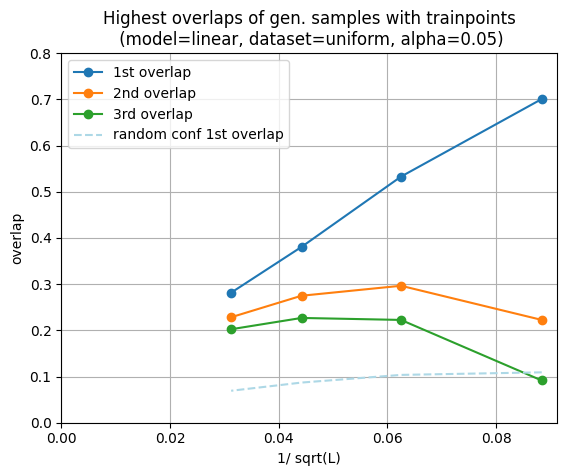

In [446]:
# plot first, second and third overlap in dfq as a function of L

plt.title(f"Highest overlaps of gen. samples with trainpoints\n (model={model_t}, dataset={dataset}, alpha={alpha})")
plt.plot(1/np.sqrt(dfq.index), dfq["q1"], label="1st overlap", marker="o")
plt.plot(1/np.sqrt(dfq.index), dfq["q2"], label="2nd overlap", marker="o")
plt.plot(1/np.sqrt(dfq.index), dfq["q3"], label="3rd overlap", marker="o")



# add the theoretical curve with Gaussian approximation for the top overlap, given by sqrt(2 log(alpha*L)/ L)
L = dfq.index
# plt.plot(1/np.sqrt(L), np.sqrt(2 * np.log(alpha * L) / L), label="random conf 1st overlap", linestyle="--")
if dataset == "uniform":
    plt.plot(1/np.sqrt(L), [fake_dict[l][0] for l in L], label="random conf 1st overlap", linestyle="--", color="lightblue")

plt.xlabel("1/ sqrt(L)")
plt.ylim(0, 0.8)
plt.xlim(left=0)
plt.ylabel("overlap")
plt.legend()
plt.grid()
plt.savefig(f"notes/plots/top3_overlaps_{model_t}_{dataset}_alpha{alpha}_l2reg{l2reg}.png", dpi=300)
plt.show()


# Losses and Overlaps

In [82]:
model_t = "linear"
dataset = "uniform"
l2reg = 0.01
L = 256
freeze_mask_weights = True
df = df_all[(df_all["model"] == model_t) & (df_all["dataset"] == dataset) &\
      (df_all["l2reg"] == l2reg) & (df_all["L"] == L)]
df = df[df["freeze_mask_weights"] == freeze_mask_weights]
df = df.sort_values(by="alpha")
df = df.reset_index(drop=True)
# assert alpha values are unique
assert df["alpha"].is_unique
df

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,exp_dir,freeze_mask_weights,...,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train,val/acc,val/loss,train/l2loss,train/qV,train/qW,train/total_loss,train/acc,train/loss
0,256,0.1,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.1_l2reg0.01_fm...,NaN,True,...,-0.008714,"[0.2699609398841858, 0.20820312201976776, 0.17...",NaN,NaN,0.083448,0.0,1.668965,0.308827,0.922001,0.225379
1,256,0.2,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.2_l2reg0.01_fm...,NaN,True,...,0.010110,"[0.2555468678474426, 0.21019531786441803, 0.18...",NaN,NaN,0.076668,0.0,3.066720,0.323472,0.877097,0.246804
2,256,0.3,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.3_l2reg0.01_fm...,NaN,True,...,-0.010045,"[0.2524999976158142, 0.2137109339237213, 0.193...",NaN,NaN,0.069089,0.0,4.145345,0.350342,0.838281,0.281253
3,256,0.4,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.4_l2reg0.01_fm...,NaN,True,...,0.020910,"[0.24179688096046448, 0.2067578136920929, 0.18...",NaN,NaN,0.061634,0.0,4.930707,0.370928,0.807900,0.309294
4,256,0.5,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.5_l2reg0.01_fm...,NaN,True,...,0.009827,"[0.2399609386920929, 0.2098046839237213, 0.190...",NaN,NaN,0.054178,0.0,5.417836,0.392763,0.785728,0.338584
5,256,0.6,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.6_l2reg0.01_fm...,NaN,True,...,0.005276,"[0.24046875536441803, 0.21113280951976776, 0.1...",NaN,NaN,0.047277,0.0,5.673194,0.414853,0.763366,0.367576
6,256,0.8,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha0.8_l2reg0.01_fm...,NaN,True,...,0.002439,"[0.23984375596046448, 0.20894531905651093, 0.1...",NaN,NaN,0.035255,0.0,5.640751,0.453431,0.732969,0.418176
7,256,1.0,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha1.0_l2reg0.01_fm...,NaN,True,...,-0.007080,"[0.22863280773162842, 0.20207031071186066, 0.1...",NaN,NaN,0.026227,0.0,5.245334,0.484930,0.709146,0.458703
8,256,2.0,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha2.0_l2reg0.01_fm...,NaN,True,...,0.008057,"[0.23082031309604645, 0.2064843773841858, 0.19...",NaN,NaN,0.007229,0.0,2.891529,0.573875,0.647818,0.566646
9,256,4.0,512,uniform,10000,0.01,linear,logs/linear_uniform_L256_alpha4.0_l2reg0.01_fm...,NaN,True,...,0.001236,"[0.22382812201976776, 0.20374999940395355, 0.1...",NaN,NaN,0.001628,0.0,1.302789,0.631515,0.605140,0.629886


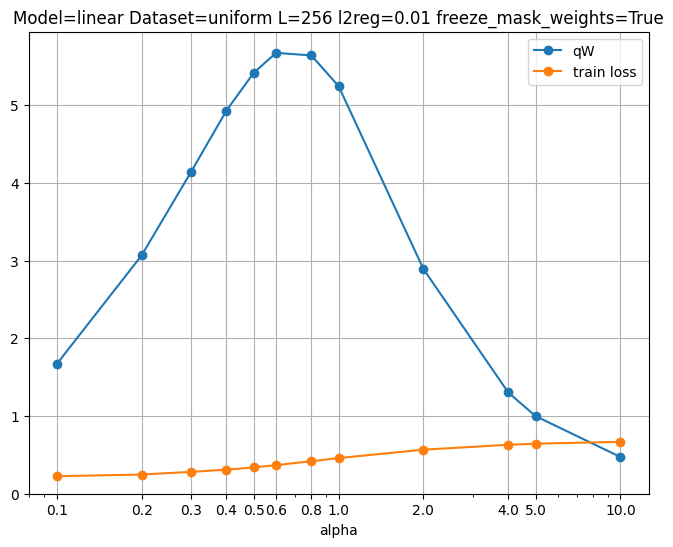

In [87]:
## plot qW and train loss as a function of alpha
plt.close("all")
plt.figure(figsize=(8,6))
plt.xlabel("alpha")
plt.title(f"Model={model_t} Dataset={dataset} L={L} l2reg={l2reg} freeze_mask_weights={freeze_mask_weights}")
plt.plot(df["alpha"], df["train/qW"], label="qW", marker="o")
plt.plot(df["alpha"], df["train/loss"], label="train loss", marker="o")
plt.ylim(0, None)
plt.xscale("log")
# put more ticks' labels, don't use scientific notation
plt.xticks(df["alpha"], [f"{a:.1f}" for a in df["alpha"]])
plt.legend()
plt.grid()
# plt.savefig(f"notes/plots/qW_loss_{model_t}_{dataset}_L{L}_l2reg{l2reg}_freeze{freeze_mask_weights}.png", dpi=300)
plt.show()


# Load Checkpoints

We load and if necessary fix (e.g. create samples and log statistics) the checkpoints.

In [109]:
import argparse
import os
import torch
from torch.utils.data import DataLoader, Subset
import json
import socket
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from datasets import UniformIsingDataset, RandomFeaturesDataset
from diffusion import MaskedDiffusion

In [127]:
alpha = 0.5
l2reg = 0.0
dataset = "uniform"
model_str = "linear"
df = df_all[(df_all["alpha"] == alpha) & (df_all["l2reg"] == l2reg) & (df_all["dataset"] == dataset) & (df_all["model"] == model_str)]
df = df[df.L < 8000]
df = df.reset_index(drop=True)
df


,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,train/acc,train/loss,...,train/acc_t0.5,train/loss_t0.9,train/acc_t0.9,train/loss_t1.0,train/acc_t1.0,train/uturn_overlap_t0.1,train/uturn_overlap_t0.5,train/uturn_overlap_t0.9,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train
0,256,0.5,512,uniform,5000,0.0,linear,logs/linear_uniform_L256_alpha0.5_l2reg0.0/ver...,0.782933,0.310531,...,0.883777,0.613921,0.669585,0.693436,0.528870,0.994263,0.843628,0.240967,0.028198,NaN
1,256,0.5,512,uniform,5000,0.0,linear,logs/linear_uniform_L256_alpha0.5_l2reg0.0/ver...,0.770171,0.312133,...,0.882644,0.619209,0.665396,0.694454,0.523987,0.995117,0.838318,0.257263,0.011047,NaN
2,512,0.5,512,uniform,5000,0.0,linear,logs/linear_uniform_L512_alpha0.5_l2reg0.0/ver...,0.799542,0.273338,...,0.880530,0.627615,0.663157,0.697903,0.513443,0.994827,0.839050,0.243988,0.004395,NaN
3,2048,0.5,512,uniform,5000,0.0,linear,logs/linear_uniform_L2048_alpha0.5_l2reg0.0/ve...,0.781464,0.315266,...,0.877663,0.642291,0.658897,0.708504,0.502551,0.995211,0.842231,0.243839,0.000275,NaN
4,4096,0.5,512,uniform,5000,0.0,linear,logs/linear_uniform_L4096_alpha0.5_l2reg0.0/ve...,0.771743,0.325373,...,0.873030,0.660258,0.653592,0.724963,0.500774,0.995115,0.840989,0.242432,0.000497,NaN


In [128]:
for run_dir in df["run_dir"]:
    model, train_data, val_data = load_model_and_data(run_dir)
    sample_path = os.path.join(run_dir, "samples.pt")
    if os.path.exists(sample_path):
        samples = torch.load(sample_path)
    else:
        samples = model.sample(200)
        torch.save(samples.cpu(), sample_path)

In [114]:
(model.backbone.W**2).mean()

tensor(0.0348, grad_fn=<MeanBackward0>)

# Binarized MNIST Dataset

In [35]:
%load_ext autoreload
%autoreload 2
from datasets import BinarizedMNIST
import matplotlib.pyplot as plt
from diffusion import MaskedDiffusion

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
dtrain = BinarizedMNIST(train=True)

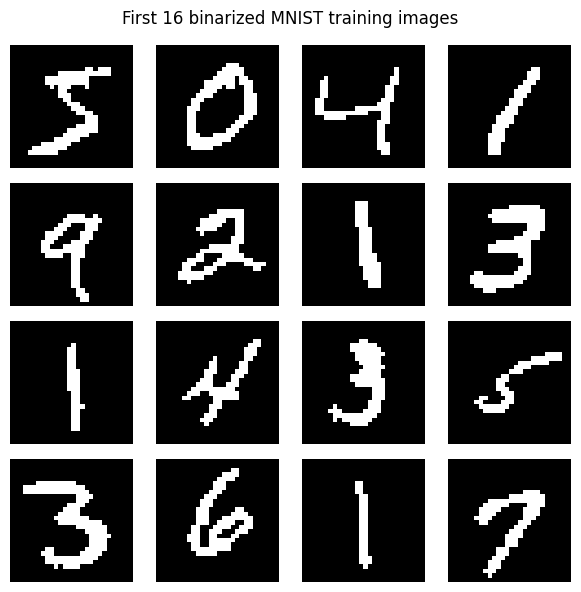

In [37]:
def plot16(data, title="", cmap="gray"):
    plt.close("all")
    plt.figure(figsize=(6,6))
    for i in range(16):
        img = data[i].reshape(28,28)
        plt.subplot(4,4,i+1)
        plt.imshow(img.squeeze(), cmap=cmap)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
plot16(dtrain, title="First 16 binarized MNIST training images")

In [38]:
dataset = "binarized_mnist"
model_str = "linear"
L = 784
alpha = 1.0
l2reg = 0.0
df = df_all[(df_all["dataset"] == dataset) & (df_all["model"] == model_str) & (df_all["L"] == L) & (df_all["alpha"] == alpha) & (df_all["l2reg"] == l2reg)]
df = df.reset_index(drop=True)
df

,L,alpha,batch_size,dataset,epochs,l2reg,model,run_dir,exp_dir,freeze_mask_weights,...,train/uturn_overlap_t1.0,sample/top3_overlaps_with_train,train/l2loss,train/qV,train/qW,train/total_loss,val/acc,val/loss,train/acc,train/loss
0,784,1.0,512,binarized_mnist,10000,0.0,linear,logs/linear_binarized_mnist_L784_alpha1.0_l2re...,NaN,False,...,NaN,NaN,0.0,3.977633,23.019995,0.089016,0.929678,0.148439,0.94496,0.089016


In [39]:
model = MaskedDiffusion.load_from_checkpoint(df.loc[0, "run_dir"] + "/last.ckpt").cpu()

In [40]:
num_train_samples = int(round(alpha * L))
# train_data = torch.cat([dtrain[i] for i in range(num_train_samples)], dim=-1)
# concatenate along the batch dimension
train_data = torch.cat([dtrain[i].view(1, -1) for i in range(num_train_samples)], dim=0)
val_data = torch.cat([dtrain[i].view(1, -1) for i in range(num_train_samples, 2 * num_train_samples)], dim=0)
train_data.shape

torch.Size([784, 784])

In [41]:
def occlude_bottom_half(x):
    x_occluded = x.clone()
    x_occluded[:, 14*28:] = 0.0
    return x_occluded

xt = occlude_bottom_half(train_data)
xt_val = occlude_bottom_half(val_data)

In [42]:
xhat = model.sample(nsamples=xt.shape[0], xt=xt)

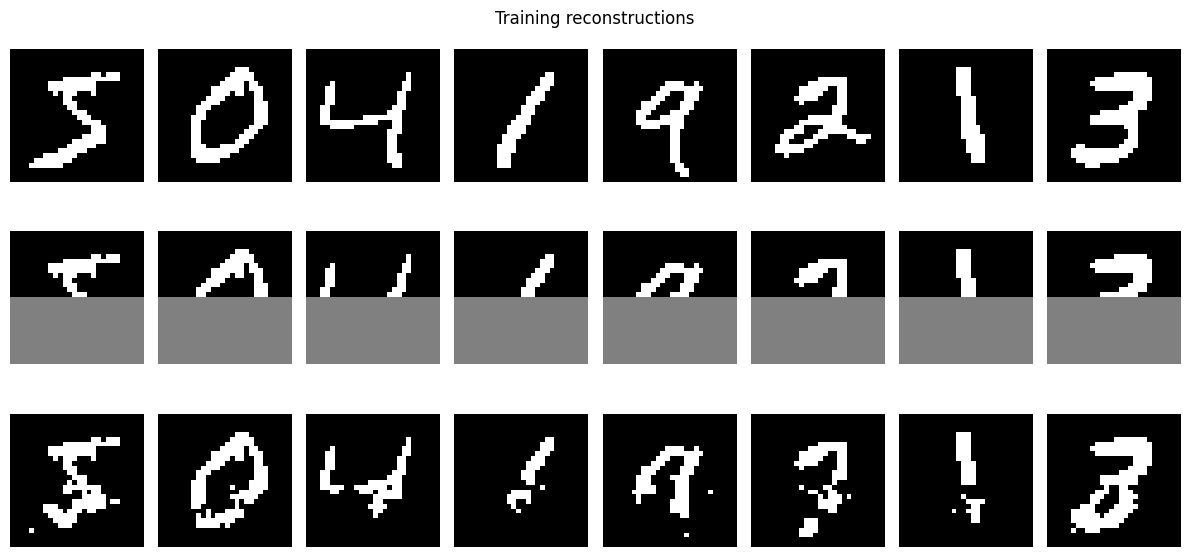

In [43]:
def plot_reconstructions(original, occluded, reconstructed, n=8, title="Reconstruction of samples (top: original, middle: occluded, bottom: reconstructed)"):
    plt.close("all")
    plt.figure(figsize=(12,6))
    for i in range(n):
        # original
        plt.subplot(3,n,i+1)
        img = original[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Original")
        plt.axis("off")
        # occluded
        plt.subplot(3,n,i+1+n)
        img = occluded[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Occluded")
        plt.axis("off")
        # reconstructed
        plt.subplot(3,n,i+1+2*n)
        img = reconstructed[i].reshape(28,28)
        plt.imshow(img.squeeze(), cmap="gray")
        # plt.title("Reconstructed")
        plt.axis("off")
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    
plot_reconstructions(train_data, xt, xhat, n=8, title="Training reconstructions")

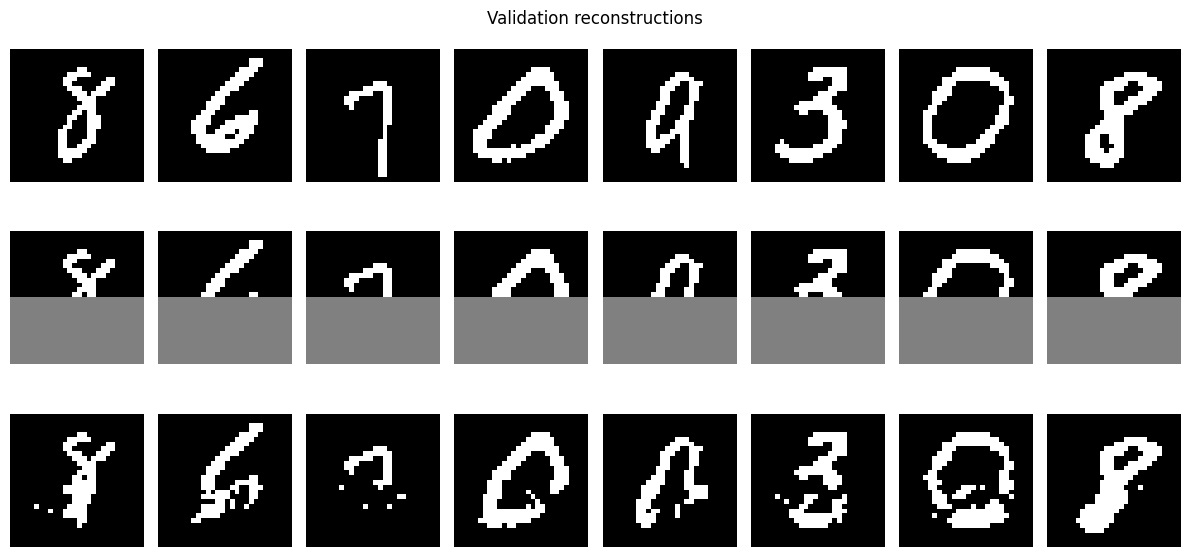

In [44]:
xhat_val = model.sample(nsamples=xt_val.shape[0], xt=xt_val)
plot_reconstructions(val_data, xt_val, xhat_val, n=8, title="Validation reconstructions")